In house‑rent prediction, linear regression models the relationship between rental price and features like size, number of bedrooms, and bathrooms. The model learns coefficients that quantify how much rent changes per unit increase in each feature.

Linear regression models the relationship between:
Independent variables (X) → house attributes
Dependent variable (y) → rent
It assumes: Rent changes linearly with house features

Now consider: Features - Size (House size in sq.ft), BHK(Number of bedrooms), Bathrooms(Number of bathrooms)

Model equation:

"Rent"=b_0+b_1("Size")+b_2("BHK")+b_3("Bathrooms")

Example learned coefficients:

"Rent"=2000+15("Size")+3000("BHK")+2000("Bathrooms")

Interpretation +₹15 per extra sq.ft +₹3000 per extra bedroom +₹2000 per extra bathroom This matches how real house rent datasets are modeled in practice.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from sklearn.linear_model import LinearRegression
import pandas as pd

In [4]:
housedatadf = pd.read_csv('house_rental_data.csv', index_col='Unnamed: 0')
housedatadf

,Sqft,Floor,TotalFloor,Bedroom,Living.Room,Bathroom,Price
1,1177.698,2,7,2,2,2,62000
2,2134.800,5,7,4,2,2,78000
3,1138.560,5,7,2,2,1,58000
4,1458.780,2,7,3,2,2,45000
5,967.776,11,14,3,2,2,45000
...,...,...,...,...,...,...,...
644,1359.156,7,15,3,2,2,45000
645,377.148,4,10,1,1,1,24800
646,740.064,13,14,1,1,1,45000
647,1707.840,3,14,3,2,2,65000


In [5]:
housedatadf.rename(columns={'Living.Room':'Livingroom'}, inplace=True)
housedatadf.head()

,Sqft,Floor,TotalFloor,Bedroom,Livingroom,Bathroom,Price
1,1177.698,2,7,2,2,2,62000
2,2134.800,5,7,4,2,2,78000
3,1138.560,5,7,2,2,1,58000
4,1458.780,2,7,3,2,2,45000
5,967.776,11,14,3,2,2,45000


In [6]:
feature_data = housedatadf.drop('Price', axis=1)
target_data = housedatadf['Price']


In [7]:
from sklearn.model_selection import train_test_split
trainX,testX, trainY,testY = train_test_split(feature_data, target_data, test_size = 0.2, random_state=42)

trainX.shape

(516, 6)

In [8]:
testX.shape

(129, 6)

In [9]:
lr = LinearRegression()
lr.fit(trainX,trainY)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 36.61, 986.52, 167.85, -784.24,-3279.99, 2798.77]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Sqft','Floor','TotalFloor','Bedroom','Livingroom','Bathroom']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1494
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [10]:
print(lr.intercept_)
print(lr.coef_)

# coef_ stores the estimated coefficients (weights/slopes) of the linear regression model, one for each input feature

# "Rent"=b_0+b_1("Size")+b_2("BHK")+b_3("Bathrooms")
# b0 → intercept (lr.intercept_)
# b1, b2, … bn → coefficients (lr.coef_)

1494.1294827821039
[   36.61020025   986.52413637   167.85117108  -784.23521376
 -3279.98982581  2798.76564178]


In [11]:
testX[:5]

,Sqft,Floor,TotalFloor,Bedroom,Livingroom,Bathroom
636,1099.422,2,7,4,2,2
596,1102.980,2,4,2,2,2
603,1458.780,21,27,3,2,2
295,761.412,8,13,1,1,1
73,1892.856,2,7,4,2,3


In [12]:
testY[:5]

636    57777
596    31000
603    60000
295    26000
73     90000
Name: Price, dtype: int64

In [13]:
predY = lr.predict(testX)

In [14]:
predY[:5]

array([40792.80631354, 41987.98232034, 76834.19188275, 38178.37419571,
       72639.34958361])

<Axes: >

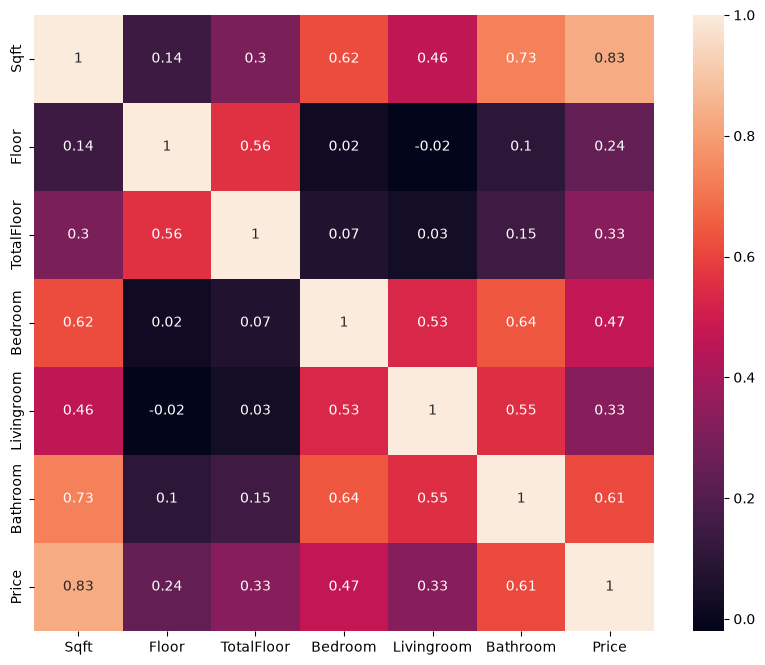

In [15]:
corr_mat = housedatadf.corr().round(2)

fig, ax = plt.subplots(figsize=(10,8))  
sns.heatmap(data=corr_mat, annot=True, ax=ax)

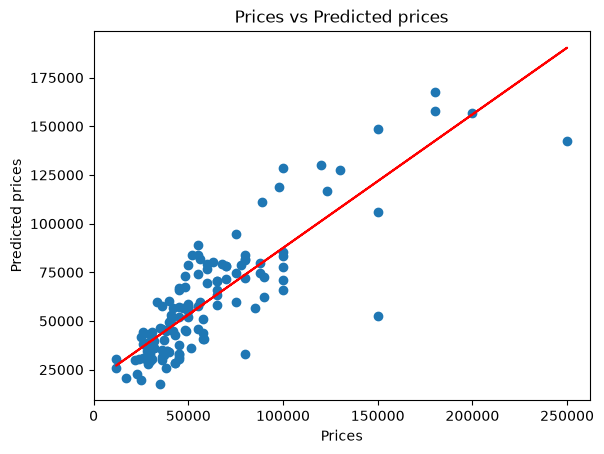

In [16]:
from numpy.polynomial import Polynomial

fig, ax1 = plt.subplots()
ax1.scatter(testY, predY)

# Fit polynomial (degree 1 = linear)
p = Polynomial.fit(testY, predY, deg=1)

ax1.plot(testY, p(testY), color='red')
ax1.set_xlabel("Prices")
ax1.set_ylabel("Predicted prices")
ax1.set_title("Prices vs Predicted prices")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


0.7202087278032021

In [18]:
# pred = lr.predict(testX)

In [19]:
# MAE measures the average absolute difference between actual and predicted values.
# Use when outliers should not dominate the metric

mean_absolute_error(y_pred=predY, y_true=testY)

13545.88926160176

In [20]:
# MSE measures the average of the squared differences between actual and predicted values. 
# Use When large errors are very costly

mean_squared_error(y_pred=predY, y_true=testY)

401487570.46258795

In [21]:

# R² measures how much variance in the target variable is explained by the model.
# Measures how well a statistical model predicts an outcome. 
# Value ranges from 0 to 1 
# The better a model is at making predictions, the closer its R² will be to 1. 
r2_score(y_pred=predY, y_true=testY)

0.7202087278032021